In [1]:
print("hello!")

hello!


In [2]:
import os
from pathlib import Path
import pandas as pd
import os
import numpy as np
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image

loading datasets . . .
Number of overlapping indices: 0
Number of overlapping groups: 0
printing example sample!


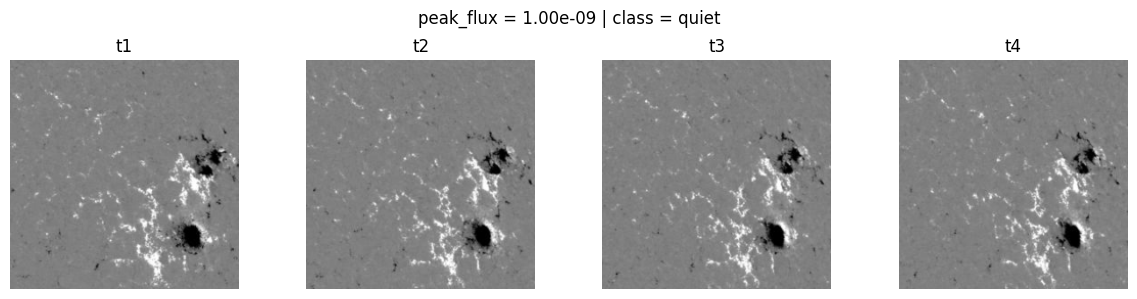

loading current models . . .
loaded current baseline model
loaded current temporal attention model
loaded current frame-difference model

========== Baseline Error Summary ==========
Mean      : 1.168349e-04
Std       : 3.076717e-05
Median    : 1.139759e-04
90th pct  : 1.382775e-04
95th pct  : 1.474737e-04
99th pct  : 1.959043e-04
Min       : 4.622544e-05
Max       : 7.771553e-04


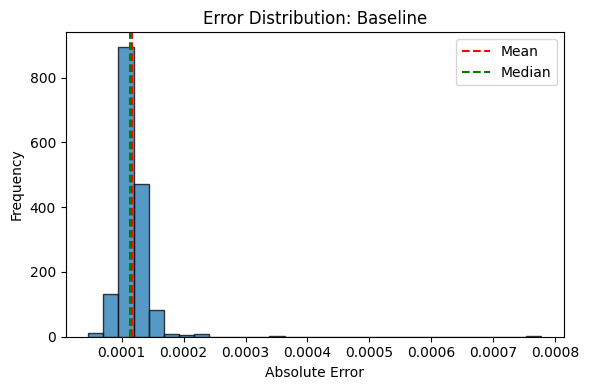


========== Temporal Attention Error Summary ==========
Mean      : 2.887211e-05
Std       : 3.346868e-05
Median    : 2.137714e-05
90th pct  : 6.031940e-05
95th pct  : 7.645789e-05
99th pct  : 1.188207e-04
Min       : 4.430650e-08
Max       : 6.698825e-04


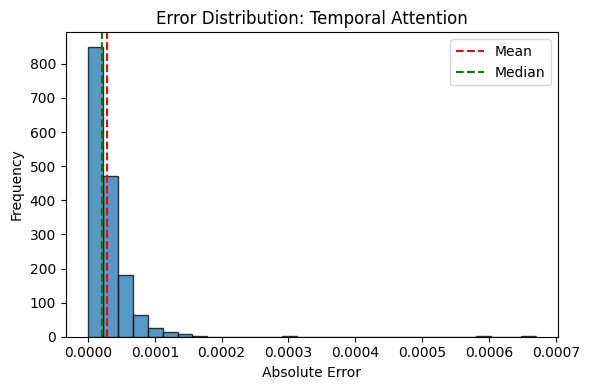


========== Temporal Difference Error Summary ==========
Mean      : 5.061758e-05
Std       : 4.250030e-05
Median    : 4.225497e-05
90th pct  : 1.021008e-04
95th pct  : 1.314910e-04
99th pct  : 1.850992e-04
Min       : 8.970147e-08
Max       : 4.973243e-04


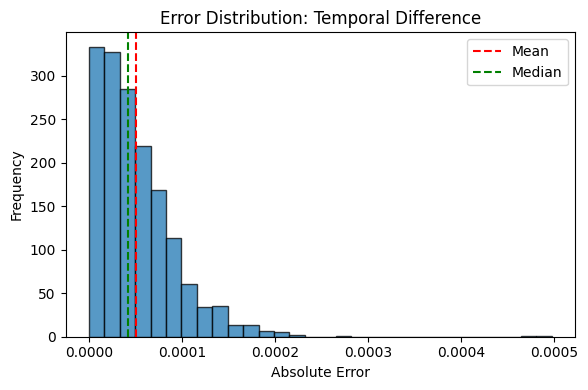

printing grad-cam example: 


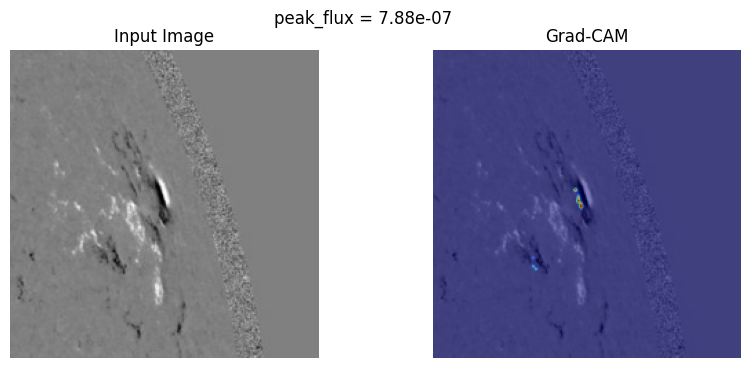

In [3]:
%run project.ipynb

In [34]:
test_loader_single = DataLoader(test_single, batch_size=32, shuffle=False)
train_loader_single = DataLoader(train_sin, batch_size=32, shuffle=True)
val_loader_single = DataLoader(val_sin, batch_size=32, shuffle=False)

In [15]:
# train in epochs
epochs = 10

In [19]:
len(train_seq)

6126

In [18]:
len(val_sin)

1620

## Baseline Training

In [20]:
# make model with L1 loss function (MAE)
model = BaselineCNN().to(device)
loss_fn = nn.L1Loss()
# optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

best_val_loss = float('inf')
patience = 4              # how many bad epochs to tolerate
epochs_no_improve = 0
min_delta = 1e-4
epochs = 15
best_model_state = None

for epoch in range(epochs):
    # training
    model.train()
    # accumulate loss
    train_loss = 0
    # for input images and labels
    for x, y, z in train_loader_single:
        # move data to device
        x = x.to(device).float()
        y = y.to(device).float()
        # reset gradients - torch accumulates and stacks gradients by defualt
        # clears old gradients in between batches
        optimizer.zero_grad()
        # forward pass, we get predictions
        preds = model(x)
        # compute loss 
        loss = loss_fn(preds, y)
        # backward propagation (computes gradients of loss for all model parameters)
        # learning signal
        loss.backward()
        # update weights/model params using gradients
        optimizer.step()
        # acc loss
        train_loss += loss.item()
    # average loss
    train_loss /= len(train_loader)

    # validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y, z in val_loader_single:
            # move data to device
            x = x.to(device).float()
            y = y.to(device).float()
            # prediciton
            preds = model(x)
            # loss 
            loss = loss_fn(preds, y)
            # acc loss
            val_loss += loss.item()

    # average validation los
    val_loss /= len(val_loader)
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_model_state = model.state_dict()  # save best weights
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

Epoch 1/15 | Train Loss: 0.001954 | Val Loss: 0.000400
Epoch 2/15 | Train Loss: 0.000147 | Val Loss: 0.000051
Epoch 3/15 | Train Loss: 0.000239 | Val Loss: 0.000162
Epoch 4/15 | Train Loss: 0.000192 | Val Loss: 0.000157
Epoch 5/15 | Train Loss: 0.000175 | Val Loss: 0.000063
Epoch 6/15 | Train Loss: 0.000162 | Val Loss: 0.000117
Early stopping triggered at epoch 6


In [31]:
model.load_state_dict(best_model_state)
model.eval()
test_loss = 0
with torch.no_grad():
    for x, y, z in test_loader_single:
        x = x.to(device).float()
        y = y.to(device).float()

        preds = model(x)
        loss = loss_fn(preds, y)

        test_loss += loss.item()

test_loss /= len(test_loader)

print("Final Test Loss:", test_loss)

Final Test Loss: 0.00012316565866617917


In [32]:
torch.save(best_model_state, "baseline_full.pth")

## Temporal Attention Training

In [ ]:
test_loader = DataLoader(test_sequence, batch_size=16, shuffle=False)
train_loader = DataLoader(train_seq, batch_size=16, shuffle=True)
val_loader = DataLoader(val_seq, batch_size=16, shuffle=False)

In [ ]:
# use baseline cnn as shared encoder inside temporal model
model = AttentionTemporalCNN().to(device)

loss_fn = nn.L1Loss()

# optimizer (slightly lower lr for stability with attention + CNN)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# learning rate scheduler (reduces LR if val loss plateaus)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

# early stopping setup
best_val = float('inf')
patience = 4
no_improve = 0
best_state = None

epochs = 15

for epoch in range(epochs):
    # training
    model.train()
    train_loss = 0

    for x, y, z in train_loader:
        x = x.to(device).float()   # [B, 4, 1, H, W]
        y = y.to(device).float()

        optimizer.zero_grad()

        # forward pass
        preds, attn = model(x)

        # loss computation
        loss = loss_fn(preds, y)

        # backward pass
        loss.backward()

        # stabilize gradients (important for attention models)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # validation
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for x, y, z in val_loader:
            x = x.to(device).float()
            y = y.to(device).float()

            preds, attn = model(x)

            loss = loss_fn(preds, y)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    # step scheduler based on validation loss
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{epochs} | Train: {train_loss:.6f} | Val: {val_loss:.6f}")

    # early stopping + best model tracking
    if val_loss < best_val:
        best_val = val_loss
        no_improve = 0

        # IMPORTANT: deep copy model weights (prevents overwrite bug)
        best_state = {k: v.clone().detach() for k, v in model.state_dict().items()}
    else:
        no_improve += 1

    if no_improve >= patience:
        print("Early stopping triggered")
        break

# restore best model after training
if best_state is not None:
    model.load_state_dict(best_state)

In [ ]:
test_loss = 0
all_preds = []
all_targets = []
all_attn = []
model.eval()
with torch.no_grad():
    for x, y, z in test_loader:
        x = x.to(device).float()
        y = y.to(device).float()

        preds, attn = model(x)
        loss = loss_fn(preds, y)
        test_loss += loss.item()

        all_preds.append(preds.cpu())
        all_targets.append(y.cpu())
        all_attn.append(attn.cpu())

test_loss /= len(test_loader)

print(f"Final Test Loss: {test_loss:.6f}")

all_attn = torch.cat(all_attn, dim=0)   # [N, 4, 1]
mean_attn = all_attn.mean(dim=0).squeeze()  # [4]
print(mean_attn)

Final Test Loss: 0.000039
tensor([0.2500, 0.2500, 0.2500, 0.2500])


In [ ]:
torch.save(model.state_dict(), "attention_full.pth")

## Frame Difference Training

In [9]:
test_loader = DataLoader(test_sequence, batch_size=16, shuffle=False, num_workers = 0)
train_loader = DataLoader(train_seq, batch_size=16, shuffle=True, num_workers = 0)
val_loader = DataLoader(val_seq, batch_size=16, shuffle=False, num_workers = 0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
base_cnn = BaselineCNN().to(device)
model = FrameDiffModel(base_cnn).to(device)

loss_fn = nn.L1Loss()

# optimizer (slightly lower lr for stability)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

# early stopping setup
best_val = float('inf')
patience = 4
no_improve = 0
best_state = None

epochs = 15

for epoch in range(epochs):
    # training
    model.train()
    train_loss = 0

    for i, (x, y, _) in enumerate(train_loader):
        x = x.to(device).float()   # [B, 4, 1, H, W]
        y = y.to(device).float()

        optimizer.zero_grad()

        preds = model(x)           # [B]

        loss = loss_fn(preds, y)

        loss.backward()

        # stabilize gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # validation
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for x, y, _ in val_loader:
            x = x.to(device).float()
            y = y.to(device).float()

            preds = model(x)

            loss = loss_fn(preds, y)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    # step scheduler based on validation loss
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{epochs} | Train: {train_loss:.6f} | Val: {val_loss:.6f}")

    # early stopping + best model tracking
    if val_loss < best_val:
        best_val = val_loss
        no_improve = 0

        # deep copy weights
        best_state = {k: v.clone().detach() for k, v in model.state_dict().items()}
    else:
        no_improve += 1

    if no_improve >= patience:
        print("Early stopping triggered")
        break

# restore best model after training
if best_state is not None:
    model.load_state_dict(best_state)

Epoch 1/15 | Train: 0.000457 | Val: 0.000490
Epoch 2/15 | Train: 0.000240 | Val: 0.000075
Epoch 3/15 | Train: 0.000210 | Val: 0.000123
Epoch 4/15 | Train: 0.000227 | Val: 0.000245
Epoch 5/15 | Train: 0.000240 | Val: 0.000051
Epoch 6/15 | Train: 0.000213 | Val: 0.000097
Epoch 7/15 | Train: 0.000167 | Val: 0.000289
Epoch 8/15 | Train: 0.000190 | Val: 0.000171
Epoch 9/15 | Train: 0.000091 | Val: 0.000156
Early stopping triggered


In [13]:
test_loss = 0
all_preds = []
all_targets = []

model.eval()  # or diffmodel if that's your variable name

with torch.no_grad():
    for x, y, _ in test_loader:
        x = x.to(device).float()   # [B, T, C, H, W]
        y = y.to(device).float()

        preds = model(x)      # [B] (no attention output)
        loss = loss_fn(preds, y)

        test_loss += loss.item()

        all_preds.append(preds.cpu())
        all_targets.append(y.cpu())

test_loss /= len(test_loader)

print(f"Final Test Loss: {test_loss:.6f}")

Final Test Loss: 0.000061


In [14]:
torch.save(model.state_dict(), "framediff_full.pth")